### Overview

Evaluation of raw counts-based machine learning models using the SCAN-B HiSeq held-out test set (20%)

Raw count normalization pipeline: PyDESeq2 median of ratios normalization --> Log2 transformation --> Standardization

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pydeseq2.preprocessing import deseq2_norm_fit, deseq2_norm_transform
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import random
import seaborn as sns
import matplotlib.pyplot as plt

#### 1. Import and prepare data

In [2]:
# import raw counts training set
train_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_raw_counts_subtype_train_80.csv", 
                          header=0, index_col=0)

In [3]:
# import validation data
val_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_raw_counts_subtype_test_20.csv", 
                          header=0, index_col=0)

In [4]:
# keep only PAM50 gene counts
X_train = train_data.iloc[:, 0:50]
X_test = val_data.iloc[:,0:50]
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.equals(X_test.columns))

(2204, 50)
(551, 50)
True


In [5]:
# save sample subtype info separately as y_train and y_test
y_train = train_data.iloc[:, [50]]
y_test = val_data.iloc[:,[50]]
print(y_train.shape)
print(y_test.shape)

(2204, 1)
(551, 1)


In [6]:
# check if the indices of x and y match
print(X_train.index.equals(y_train.index))
print(X_test.index.equals(y_test.index))

True
True


In [7]:
# label encoding
label_encoder = LabelEncoder()
y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
y_test['subtype'] = label_encoder.transform(y_test['subtype'])

# check class count before label encoding
print("Class count before label encoding")
print("Train set\n",train_data['subtype'].value_counts())
print("\nTest set\n",val_data['subtype'].value_counts())

# check class count after label encoding
print("\nClass count after label encoding")
print("Train set\n",y_train['subtype'].value_counts())
print("\nTest set\n",y_test['subtype'].value_counts())

Class count before label encoding
Train set
 subtype
LumA     1119
LumB      654
Basal     230
Her2      201
Name: count, dtype: int64

Test set
 subtype
LumA     279
LumB     164
Basal     58
Her2      50
Name: count, dtype: int64

Class count after label encoding
Train set
 subtype
2    1119
3     654
0     230
1     201
Name: count, dtype: int64

Test set
 subtype
2    279
3    164
0     58
1     50
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_19608\535389317.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
C:\Users\User\AppData\Local\Temp\ipykernel_19608\535389317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['subtype'] = label_encoder.transform(y_test['subtype'])


#### 2. Evaluate model performance on the test set

In [8]:
# define seed and initialize random values
seed = 42
random.seed(seed)
np.random.seed(seed)

#### 2.1 Random Forest

In [9]:
random.seed(seed)
np.random.seed(seed)

# perform pydeseq2 median of ratios normalization
logMeans, filteredGenes = deseq2_norm_fit(X_train)
x_train_deseq2 = deseq2_norm_transform(X_train, logMeans, filteredGenes)[0]
x_test_deseq2 = deseq2_norm_transform(X_test, logMeans, filteredGenes)[0]

# perform log2 transformation
x_train_log2 = np.log2(x_train_deseq2 + 1)
x_test_log2 = np.log2(x_test_deseq2 + 1)
   
# perform standardization
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_log2)
x_test_scaled = scaler.transform(x_test_log2)

x_train_scaled = pd.DataFrame(x_train_scaled, index=x_train_log2.index, columns=x_train_log2.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, index=x_test_log2.index, columns=x_test_log2.columns)
   
print(f"Shape of X_train and X_test sets: {x_train_scaled.shape} and {x_test_scaled.shape}")
print(f"Shape of y_train and y_test sets: {y_train.shape} and {y_test.shape}")
print(f"Columns of x train and x test match: {x_train_scaled.columns.equals(x_test_scaled.columns)}")
     
# build rf classifier
rfc = RandomForestClassifier(n_estimators=200, min_samples_leaf=1, min_samples_split=4, max_depth=None, random_state=seed)

# fit the rf classifier on the training fold sets
rfc.fit(x_train_scaled, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_rf = rfc.predict(x_test_scaled)

# calculate metric scores
mcc_rf = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_rf)
f1_rf = metrics.f1_score(y_test.values.ravel(), y_pred_rf, average='macro')
recall_rf = metrics.recall_score(y_test.values.ravel(), y_pred_rf, average='macro')
precision_rf = metrics.precision_score(y_test.values.ravel(), y_pred_rf, average='macro')
accuracy_rf = metrics.accuracy_score(y_test.values.ravel(), y_pred_rf)

print(metrics.classification_report(y_test.values.ravel(), y_pred_rf, digits=4))


Shape of X_train and X_test sets: (2204, 50) and (551, 50)
Shape of y_train and y_test sets: (2204, 1) and (551, 1)
Columns of x train and x test match: True
              precision    recall  f1-score   support

           0     1.0000    0.9828    0.9913        58
           1     1.0000    0.9200    0.9583        50
           2     0.9472    0.9642    0.9556       279
           3     0.9146    0.9146    0.9146       164

    accuracy                         0.9474       551
   macro avg     0.9655    0.9454    0.9550       551
weighted avg     0.9478    0.9474    0.9474       551



In [10]:
print('Accuracy: ', round(accuracy_rf,4))
print('Macro Precision: ', round(precision_rf,4))
print('Macro Recall: ', round(recall_rf,4))
print('Macro F1: ', round(f1_rf,4))
print('Macro MCC: ', round(mcc_rf,4))

Accuracy:  0.9474
Macro Precision:  0.9655
Macro Recall:  0.9454
Macro F1:  0.955
Macro MCC:  0.9168


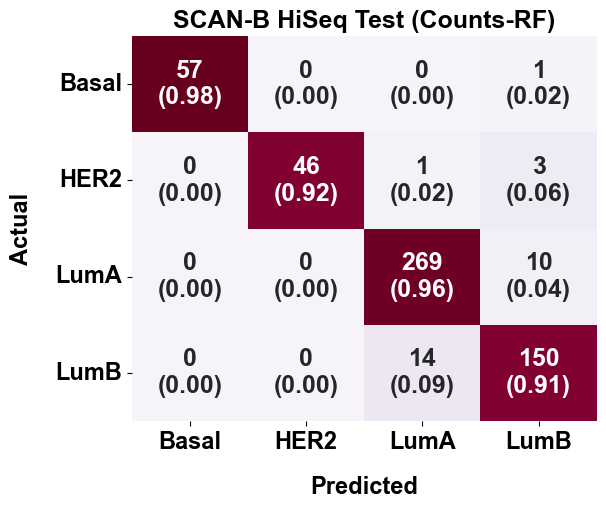

In [11]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_rf, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_rf, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('SCAN-B HiSeq Test (Counts-RF)', fontsize=18, fontfamily='Arial', weight='bold')
# plt.savefig('scanbhiseq_test_counts_rf_confusionmatrix.png',dpi=300, bbox_inches='tight')
plt.show()

#### 2.2 SVM

In [12]:
random.seed(seed)
np.random.seed(seed)

# perform pydeseq2 median of ratios normalization
logMeans, filteredGenes = deseq2_norm_fit(X_train)
x_train_deseq2 = deseq2_norm_transform(X_train, logMeans, filteredGenes)[0]
x_test_deseq2 = deseq2_norm_transform(X_test, logMeans, filteredGenes)[0]

# perform log2 transformation
x_train_log2 = np.log2(x_train_deseq2 + 1)
x_test_log2 = np.log2(x_test_deseq2 + 1)
   
# perform standardization
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_log2)
x_test_scaled = scaler.transform(x_test_log2)

x_train_scaled = pd.DataFrame(x_train_scaled, index=x_train_log2.index, columns=x_train_log2.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, index=x_test_log2.index, columns=x_test_log2.columns)
   
print(f"Shape of X_train and X_test sets: {x_train_scaled.shape} and {x_test_scaled.shape}")
print(f"Shape of y_train and y_test sets: {y_train.shape} and {y_test.shape}")
print(f"Columns of x train and x test match: {x_train_scaled.columns.equals(x_test_scaled.columns)}")
     
# build svm classifier
svm = SVC(kernel='rbf', gamma='scale', C=5, random_state=seed)

# fit the svm classifier on the training fold sets
svm.fit(x_train_scaled, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_svm = svm.predict(x_test_scaled)

# calculate metric scores
mcc_svm = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_svm)
f1_svm = metrics.f1_score(y_test.values.ravel(), y_pred_svm, average='macro')
recall_svm = metrics.recall_score(y_test.values.ravel(), y_pred_svm, average='macro')
precision_svm = metrics.precision_score(y_test.values.ravel(), y_pred_svm, average='macro')
accuracy_svm = metrics.accuracy_score(y_test.values.ravel(), y_pred_svm)

print(metrics.classification_report(y_test.values.ravel(), y_pred_svm, digits=4))


Shape of X_train and X_test sets: (2204, 50) and (551, 50)
Shape of y_train and y_test sets: (2204, 1) and (551, 1)
Columns of x train and x test match: True
              precision    recall  f1-score   support

           0     1.0000    0.9828    0.9913        58
           1     0.9574    0.9000    0.9278        50
           2     0.9571    0.9606    0.9589       279
           3     0.9042    0.9207    0.9124       164

    accuracy                         0.9456       551
   macro avg     0.9547    0.9410    0.9476       551
weighted avg     0.9459    0.9456    0.9456       551



In [13]:
print('Accuracy: ', round(accuracy_svm,4))
print('Macro Precision: ', round(precision_svm,4))
print('Macro Recall: ', round(recall_svm,4))
print('Macro F1: ', round(f1_svm,4))
print('Macro MCC: ', round(mcc_svm,4))

Accuracy:  0.9456
Macro Precision:  0.9547
Macro Recall:  0.941
Macro F1:  0.9476
Macro MCC:  0.9142


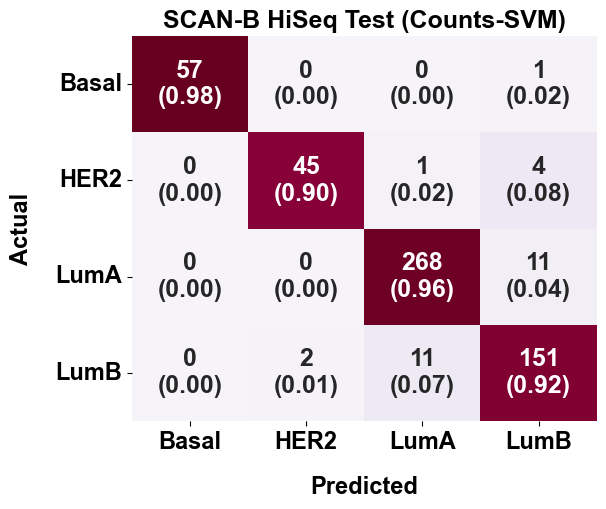

In [14]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_svm, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_svm, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('SCAN-B HiSeq Test (Counts-SVM)', fontsize=18, fontfamily='Arial', weight='bold')
# plt.savefig('scanbhiseq_test_counts_svm_confusionmatrix.png',dpi=300, bbox_inches='tight')
plt.show()

#### 2.3 Logistic Regression

In [15]:
random.seed(seed)
np.random.seed(seed)

# perform pydeseq2 median of ratios normalization
logMeans, filteredGenes = deseq2_norm_fit(X_train)
x_train_deseq2 = deseq2_norm_transform(X_train, logMeans, filteredGenes)[0]
x_test_deseq2 = deseq2_norm_transform(X_test, logMeans, filteredGenes)[0]

# perform log2 transformation
x_train_log2 = np.log2(x_train_deseq2 + 1)
x_test_log2 = np.log2(x_test_deseq2 + 1)
   
# perform standardization
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_log2)
x_test_scaled = scaler.transform(x_test_log2)

x_train_scaled = pd.DataFrame(x_train_scaled, index=x_train_log2.index, columns=x_train_log2.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, index=x_test_log2.index, columns=x_test_log2.columns)
   
print(f"Shape of X_train and X_test sets: {x_train_scaled.shape} and {x_test_scaled.shape}")
print(f"Shape of y_train and y_test sets: {y_train.shape} and {y_test.shape}")
print(f"Columns of x train and x test match: {x_train_scaled.columns.equals(x_test_scaled.columns)}")
    
# build lr classifier
logreg = LogisticRegression(C=0.1, solver='lbfgs', penalty='l2', max_iter=1000, random_state=seed)

# fit the rfc model on the training fold sets
logreg.fit(x_train_scaled, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_logreg = logreg.predict(x_test_scaled)

# calculate metric scores
mcc_logreg = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_logreg)
f1_logreg = metrics.f1_score(y_test.values.ravel(), y_pred_logreg, average='macro')
recall_logreg = metrics.recall_score(y_test.values.ravel(), y_pred_logreg, average='macro')
precision_logreg = metrics.precision_score(y_test.values.ravel(), y_pred_logreg, average='macro')
accuracy_logreg = metrics.accuracy_score(y_test.values.ravel(), y_pred_logreg)

print(metrics.classification_report(y_test.values.ravel(), y_pred_logreg, digits=4))


Shape of X_train and X_test sets: (2204, 50) and (551, 50)
Shape of y_train and y_test sets: (2204, 1) and (551, 1)
Columns of x train and x test match: True
              precision    recall  f1-score   support

           0     1.0000    0.9655    0.9825        58
           1     0.9773    0.8600    0.9149        50
           2     0.9474    0.9677    0.9574       279
           3     0.9036    0.9146    0.9091       164

    accuracy                         0.9419       551
   macro avg     0.9571    0.9270    0.9410       551
weighted avg     0.9426    0.9419    0.9418       551



In [16]:
print('Accuracy: ', round(accuracy_logreg,4))
print('Macro Precision: ', round(precision_logreg,4))
print('Macro Recall: ', round(recall_logreg,4))
print('Macro F1: ', round(f1_logreg,4))
print('Macro MCC: ', round(mcc_logreg,4))

Accuracy:  0.9419
Macro Precision:  0.9571
Macro Recall:  0.927
Macro F1:  0.941
Macro MCC:  0.9081


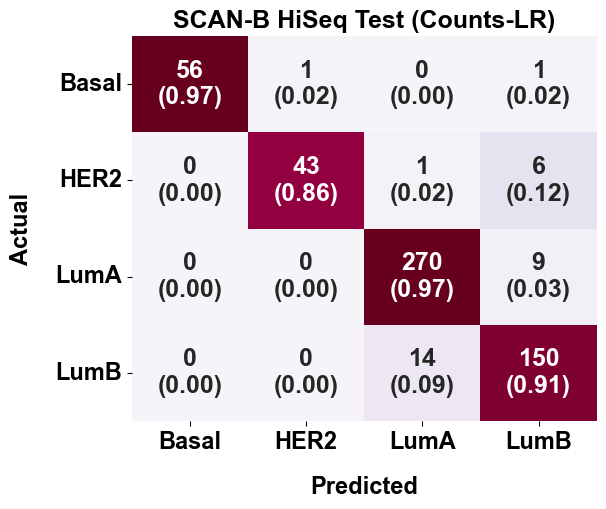

In [17]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_logreg, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_logreg, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('SCAN-B HiSeq Test (Counts-LR)', fontsize=18, fontfamily='Arial', weight='bold')
# plt.savefig('scanbhiseq_test_counts_lr_confusionmatrix.png',dpi=300, bbox_inches='tight')
plt.show()

#### 3. Merge predicted labels of random forest (best model) with actual labels and survival information

This was created for survival analysis based on model predictions.

In [18]:
# import survival and subtype data of validation set
val_survival_subtype = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_survival_data/scanb_hiseq_test20_survival_subtype.csv",
                                           header=0, index_col=0)

# reorder the rows in survival data according to the counts_subtype data
val_survival_subtype = val_survival_subtype.loc[val_data.index,:]
print('Index of survival data matches with index of gene exp data:', val_survival_subtype.index.equals(val_data.index))

# check whether the subtype column in subtype data is same as subtype column in gene exp data
print('Subtype column of survival data matches with subtype column of gene exp data:',
      val_survival_subtype['subtype'].tolist() == val_data['subtype'].tolist())

Index of survival data matches with index of gene exp data: True
Subtype column of survival data matches with subtype column of gene exp data: True


In [19]:
# define best model
best_model_res = y_pred_rf

# define labels to transform the numeric class labels into subtype names
labels_reverse = {0: 'Basal', 1: 'Her2', 2: 'LumA', 3: 'LumB'}

# convert predicted results of best model into a df
best_model_res_df = pd.DataFrame(best_model_res, index=y_test.index, columns=['predicted_subtype'])
best_model_res_df['predicted_subtype'] = best_model_res_df['predicted_subtype'].replace(labels_reverse)
best_model_res_df['predicted_subtype'].value_counts()

predicted_subtype
LumA     284
LumB     164
Basal     57
Her2      46
Name: count, dtype: int64

In [20]:
# merge survival data, actual labels and predicted labels
best_model_res_survival = val_survival_subtype.join(best_model_res_df)

# get the count of misclassifications
print('Number of misclassifications:', best_model_res_survival.loc[best_model_res_survival['subtype'] 
      != best_model_res_survival['predicted_subtype'],:].shape)

Number of misclassifications: (29, 5)


In [21]:
# check overall survival events
print("Survival event proportion:")
print(best_model_res_survival['overall_survival_event'].value_counts())

# check overall survival events as per actual labels
print("\nSurvival event proportion based on actual subtype labels:")
# check survival events with actual labels
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'LumA', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'LumB', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'Her2', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'Basal', 'overall_survival_event'].value_counts())

# check overall survival events as per predicted labels
print("\nSurvival event proportion based on predicted subtype labels:")
# check survival events with actual labels
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'LumA', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'LumB', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'Her2', 'overall_survival_event'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'Basal', 'overall_survival_event'].value_counts())

Survival event proportion:
overall_survival_event
0    475
1     76
Name: count, dtype: int64

Survival event proportion based on actual subtype labels:
overall_survival_event
0    250
1     29
Name: count, dtype: int64
overall_survival_event
0    137
1     27
Name: count, dtype: int64
overall_survival_event
0    46
1     4
Name: count, dtype: int64
overall_survival_event
0    42
1    16
Name: count, dtype: int64

Survival event proportion based on predicted subtype labels:
overall_survival_event
0    255
1     29
Name: count, dtype: int64
overall_survival_event
0    137
1     27
Name: count, dtype: int64
overall_survival_event
0    42
1     4
Name: count, dtype: int64
overall_survival_event
0    41
1    16
Name: count, dtype: int64


In [23]:
# # save predicted + actual labels + survival data
# best_model_res_survival.to_csv('scanb_hiseq_test_counts_rf_predictions.csv')